In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import seaborn as sns
import importlib
import methods
importlib.reload(methods)
from methods import ETL
from prophet import Prophet
from sklearn.metrics import mean_squared_error, r2_score

c:\Users\TobyWong\Desktop\UNCC\5122\EIA_end_customer_sales_power_prediction_NC\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


In [2]:
#Set your variables
csv_filename = 'eia_retail_sales_mwh_monthly_state_sectorwide.csv'
path = r'C:\Users\TobyWong\Desktop\UNCC\5122\EIA_end_customer_sales_power_prediction_NC\data'
stateid = 'NC'
drop_columns = ['ALL', 'OTH', 'RES', 'TRA','IND']
keep_columns = ['COM']

In [3]:
df = ETL(
    csv_filename=csv_filename,
    os_path=path,
    stateid=stateid,
    drop_columns=drop_columns,
    keep_columns=keep_columns
)
df.head(1)

,period,stateid,COM,salesUnit
31,2025-11-01,NC,3730.97423,million kilowatt hours


19:54:35 - cmdstanpy - INFO - Chain [1] start processing
19:54:36 - cmdstanpy - INFO - Chain [1] done processing
19:54:36 - cmdstanpy - INFO - Chain [1] start processing
19:54:36 - cmdstanpy - INFO - Chain [1] done processing


Test RMSE: 217.2731733556542
Test R^2: 0.7825181828997356
        period stateid               salesUnit  predicted_COM
299 2025-12-01      NC  million kilowatt hours    3830.730627
300 2026-01-01      NC  million kilowatt hours    4082.776686
301 2026-02-01      NC  million kilowatt hours    3701.581533
302 2026-03-01      NC  million kilowatt hours    3771.757863
303 2026-04-01      NC  million kilowatt hours    3754.847261
304 2026-05-01      NC  million kilowatt hours    4083.364794
305 2026-06-01      NC  million kilowatt hours    4442.920680
306 2026-07-01      NC  million kilowatt hours    4808.794596
307 2026-08-01      NC  million kilowatt hours    4823.290599
308 2026-09-01      NC  million kilowatt hours    4498.967369
309 2026-10-01      NC  million kilowatt hours    4100.622872
310 2026-11-01      NC  million kilowatt hours    3795.168319
311 2026-12-01      NC  million kilowatt hours    3879.667133
312 2027-01-01      NC  million kilowatt hours    4066.091385
313 2027-02-

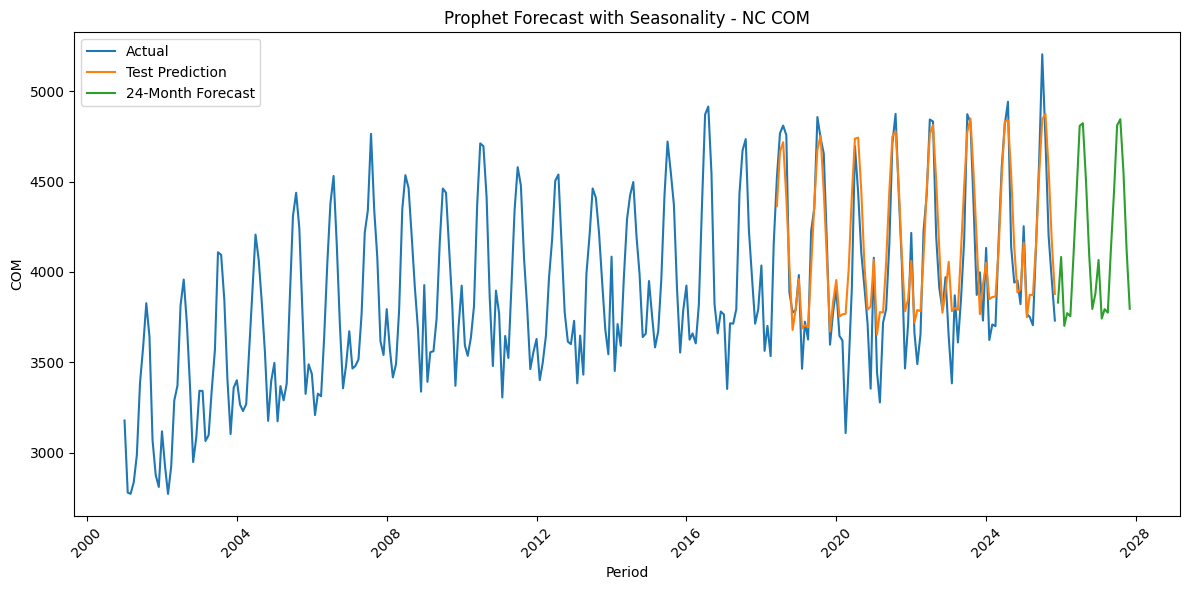

In [4]:
target_col = keep_columns[0]

# version 1
df_model = df.copy()
df_model["period"] = pd.to_datetime(df_model["period"])
df_model = df_model.sort_values("period").reset_index(drop=True)

prophet_df = df_model[["period", target_col]].rename(columns={"period": "ds", target_col: "y"})

# Train/test split (70/30)
split_idx = int(len(prophet_df) * 0.7)
train = prophet_df.iloc[:split_idx].copy()
test = prophet_df.iloc[split_idx:].copy()

# Fit Prophet model
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    seasonality_mode="additive"
)
model.fit(train)

# Predict on test set
test_forecast = model.predict(test[["ds"]])
test[f"predicted_{target_col}"] = test_forecast["yhat"].values

# Metrics
rmse = np.sqrt(mean_squared_error(test["y"], test[f"predicted_{target_col}"]))
r2 = r2_score(test["y"], test[f"predicted_{target_col}"])

print("Test RMSE:", rmse)
print("Test R^2:", r2)

# Refit on full dataset for 24-month forecast
final_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    seasonality_mode="additive"
)
final_model.fit(prophet_df)

future = final_model.make_future_dataframe(periods=24, freq="MS")
forecast = final_model.predict(future)

future_forecast = forecast[forecast["ds"] > prophet_df["ds"].max()][["ds", "yhat"]].copy()
future_forecast = future_forecast.rename(
    columns={"ds": "period", "yhat": f"predicted_{target_col}"}
)
future_forecast["stateid"] = stateid
future_forecast["salesUnit"] = "million kilowatt hours"

print(future_forecast[["period", "stateid", "salesUnit", f"predicted_{target_col}"]])

# Plot
plt.figure(figsize=(12, 6))
plt.plot(prophet_df["ds"], prophet_df["y"], label="Actual")
plt.plot(test["ds"], test[f"predicted_{target_col}"], label="Test Prediction")
plt.plot(
    future_forecast["period"],
    future_forecast[f"predicted_{target_col}"],
    label="24-Month Forecast"
)
plt.xlabel("Period")
plt.ylabel(target_col)
plt.title(f"Prophet Forecast with Seasonality - {stateid} {target_col}")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

19:54:36 - cmdstanpy - INFO - Chain [1] start processing
19:54:36 - cmdstanpy - INFO - Chain [1] done processing
19:54:36 - cmdstanpy - INFO - Chain [1] start processing
19:54:37 - cmdstanpy - INFO - Chain [1] done processing


Test RMSE: 217.2731733556542
Test R^2: 0.7825181828997356
        period stateid               salesUnit  predicted_COM
299 2025-12-01      NC  million kilowatt hours    3837.464698
300 2026-01-01      NC  million kilowatt hours    4111.521470
301 2026-02-01      NC  million kilowatt hours    3692.904588
302 2026-03-01      NC  million kilowatt hours    3776.181732
303 2026-04-01      NC  million kilowatt hours    3754.874777
304 2026-05-01      NC  million kilowatt hours    4113.871883
305 2026-06-01      NC  million kilowatt hours    4504.896554
306 2026-07-01      NC  million kilowatt hours    4901.675291
307 2026-08-01      NC  million kilowatt hours    4914.357693
308 2026-09-01      NC  million kilowatt hours    4562.810860
309 2026-10-01      NC  million kilowatt hours    4134.591637
310 2026-11-01      NC  million kilowatt hours    3808.571347
311 2026-12-01      NC  million kilowatt hours    3900.366311
312 2027-01-01      NC  million kilowatt hours    4102.767539
313 2027-02-

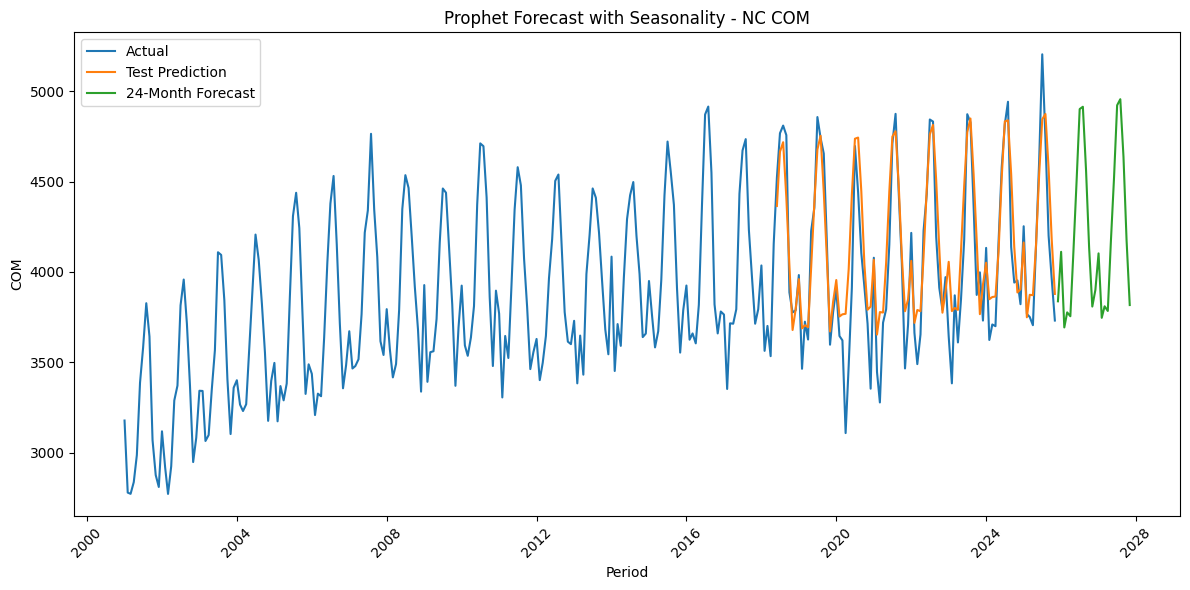

In [5]:
target_col = keep_columns[0]

# version 1
df_model = df.copy()
df_model["period"] = pd.to_datetime(df_model["period"])
df_model = df_model.sort_values("period").reset_index(drop=True)

prophet_df = df_model[["period", target_col]].rename(columns={"period": "ds", target_col: "y"})

# Train/test split (70/30)
split_idx = int(len(prophet_df) * 0.7)
train = prophet_df.iloc[:split_idx].copy()
test = prophet_df.iloc[split_idx:].copy()

# Fit Prophet model
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    seasonality_mode="additive"
)
model.fit(train)

# Predict on test set
test_forecast = model.predict(test[["ds"]])
test[f"predicted_{target_col}"] = test_forecast["yhat"].values

# Metrics
rmse = np.sqrt(mean_squared_error(test["y"], test[f"predicted_{target_col}"]))
r2 = r2_score(test["y"], test[f"predicted_{target_col}"])

print("Test RMSE:", rmse)
print("Test R^2:", r2)

# Refit on full dataset for 24-month forecast
final_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    seasonality_mode="multiplicative",
    changepoint_prior_scale=0.1,
    seasonality_prior_scale=10.0
)
final_model.fit(prophet_df)

future = final_model.make_future_dataframe(periods=24, freq="MS")
forecast = final_model.predict(future)

future_forecast = forecast[forecast["ds"] > prophet_df["ds"].max()][["ds", "yhat"]].copy()
future_forecast = future_forecast.rename(
    columns={"ds": "period", "yhat": f"predicted_{target_col}"}
)
future_forecast["stateid"] = stateid
future_forecast["salesUnit"] = "million kilowatt hours"

print(future_forecast[["period", "stateid", "salesUnit", f"predicted_{target_col}"]])

# Plot
plt.figure(figsize=(12, 6))
plt.plot(prophet_df["ds"], prophet_df["y"], label="Actual")
plt.plot(test["ds"], test[f"predicted_{target_col}"], label="Test Prediction")
plt.plot(
    future_forecast["period"],
    future_forecast[f"predicted_{target_col}"],
    label="24-Month Forecast"
)
plt.xlabel("Period")
plt.ylabel(target_col)
plt.title(f"Prophet Forecast with Seasonality - {stateid} {target_col}")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

19:54:37 - cmdstanpy - INFO - Chain [1] start processing
19:54:37 - cmdstanpy - INFO - Chain [1] done processing
19:54:37 - cmdstanpy - INFO - Chain [1] start processing
19:54:37 - cmdstanpy - INFO - Chain [1] done processing


Test RMSE: 467.9157228360832
Test R^2: 0.7632929393924969
        period stateid               salesUnit  predicted_RES
299 2025-12-01      NC  million kilowatt hours    5579.960653
300 2026-01-01      NC  million kilowatt hours    6447.630501
301 2026-02-01      NC  million kilowatt hours    5406.248393
302 2026-03-01      NC  million kilowatt hours    4873.194179
303 2026-04-01      NC  million kilowatt hours    3960.093973
304 2026-05-01      NC  million kilowatt hours    4233.045102
305 2026-06-01      NC  million kilowatt hours    5379.795175
306 2026-07-01      NC  million kilowatt hours    6448.924347
307 2026-08-01      NC  million kilowatt hours    6286.676392
308 2026-09-01      NC  million kilowatt hours    5355.780596
309 2026-10-01      NC  million kilowatt hours    4128.830781
310 2026-11-01      NC  million kilowatt hours    4219.042342
311 2026-12-01      NC  million kilowatt hours    5552.161091
312 2027-01-01      NC  million kilowatt hours    6376.436840
313 2027-02-

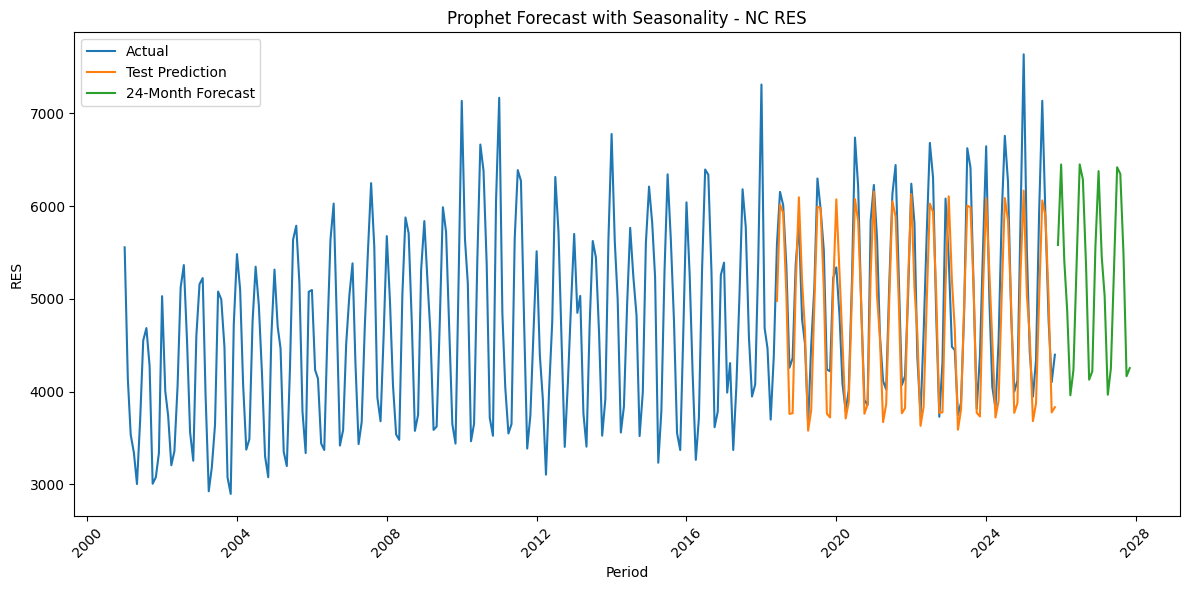

In [6]:
drop_columns = ['ALL', 'OTH', 'COM', 'TRA','IND']
keep_columns = ['RES']
df = ETL(
    csv_filename=csv_filename,
    os_path=path,
    stateid=stateid,
    drop_columns=drop_columns,
    keep_columns=keep_columns
)
target_col = keep_columns[0]

# version 1
df_model = df.copy()
df_model["period"] = pd.to_datetime(df_model["period"])
df_model = df_model.sort_values("period").reset_index(drop=True)

prophet_df = df_model[["period", target_col]].rename(columns={"period": "ds", target_col: "y"})

# Train/test split (70/30)
split_idx = int(len(prophet_df) * 0.7)
train = prophet_df.iloc[:split_idx].copy()
test = prophet_df.iloc[split_idx:].copy()

# Fit Prophet model
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    seasonality_mode="additive"
)
model.fit(train)

# Predict on test set
test_forecast = model.predict(test[["ds"]])
test[f"predicted_{target_col}"] = test_forecast["yhat"].values

# Metrics
rmse = np.sqrt(mean_squared_error(test["y"], test[f"predicted_{target_col}"]))
r2 = r2_score(test["y"], test[f"predicted_{target_col}"])

print("Test RMSE:", rmse)
print("Test R^2:", r2)

# Refit on full dataset for 24-month forecast
final_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    seasonality_mode="additive"
)
final_model.fit(prophet_df)

future = final_model.make_future_dataframe(periods=24, freq="MS")
forecast = final_model.predict(future)

future_forecast = forecast[forecast["ds"] > prophet_df["ds"].max()][["ds", "yhat"]].copy()
future_forecast = future_forecast.rename(
    columns={"ds": "period", "yhat": f"predicted_{target_col}"}
)
future_forecast["stateid"] = stateid
future_forecast["salesUnit"] = "million kilowatt hours"

print(future_forecast[["period", "stateid", "salesUnit", f"predicted_{target_col}"]])

# Plot
plt.figure(figsize=(12, 6))
plt.plot(prophet_df["ds"], prophet_df["y"], label="Actual")
plt.plot(test["ds"], test[f"predicted_{target_col}"], label="Test Prediction")
plt.plot(
    future_forecast["period"],
    future_forecast[f"predicted_{target_col}"],
    label="24-Month Forecast"
)
plt.xlabel("Period")
plt.ylabel(target_col)
plt.title(f"Prophet Forecast with Seasonality - {stateid} {target_col}")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

20:02:29 - cmdstanpy - INFO - Chain [1] start processing
20:02:29 - cmdstanpy - INFO - Chain [1] done processing
20:02:29 - cmdstanpy - INFO - Chain [1] start processing
20:02:29 - cmdstanpy - INFO - Chain [1] done processing


Test RMSE: 246.98569464423184
Test R^2: -0.372022805621691
        period stateid               salesUnit  predicted_IND
299 2025-12-01      NC  million kilowatt hours    1963.986759
300 2026-01-01      NC  million kilowatt hours    1972.949164
301 2026-02-01      NC  million kilowatt hours    1987.730253
302 2026-03-01      NC  million kilowatt hours    2068.567162
303 2026-04-01      NC  million kilowatt hours    2064.850521
304 2026-05-01      NC  million kilowatt hours    2273.298987
305 2026-06-01      NC  million kilowatt hours    2221.655616
306 2026-07-01      NC  million kilowatt hours    2259.357300
307 2026-08-01      NC  million kilowatt hours    2389.280480
308 2026-09-01      NC  million kilowatt hours    2148.313906
309 2026-10-01      NC  million kilowatt hours    2199.220500
310 2026-11-01      NC  million kilowatt hours    2152.815004
311 2026-12-01      NC  million kilowatt hours    1966.465277
312 2027-01-01      NC  million kilowatt hours    1946.475644
313 2027-02

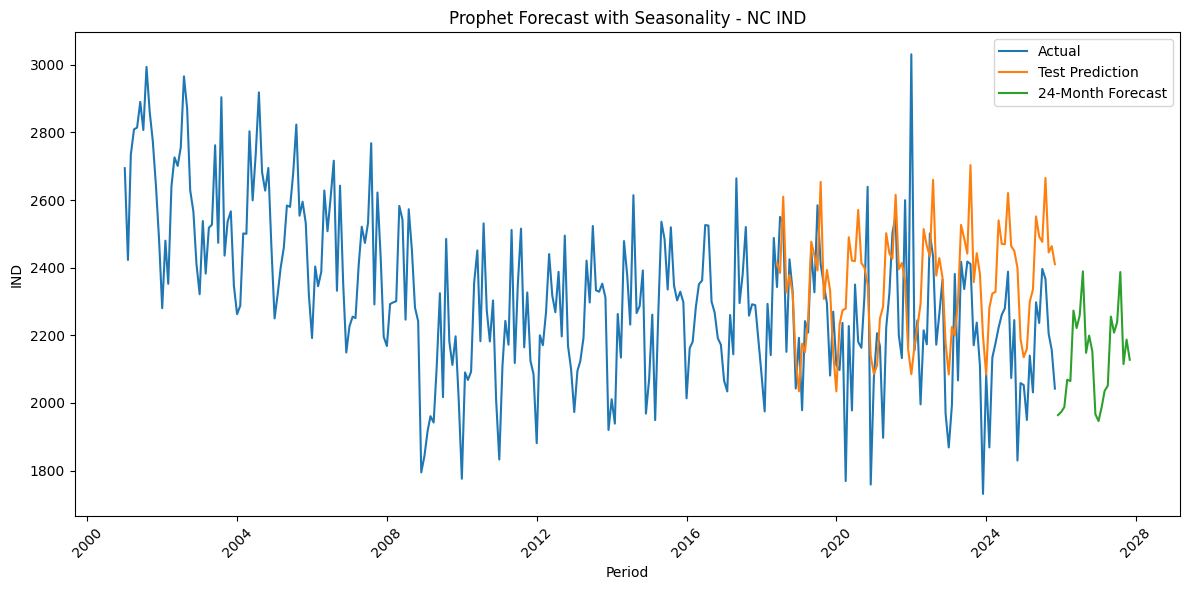

In [10]:
drop_columns = ['ALL', 'OTH', 'COM', 'TRA','RES']
keep_columns = ['IND']
df = ETL(
    csv_filename=csv_filename,
    os_path=path,
    stateid=stateid,
    drop_columns=drop_columns,
    keep_columns=keep_columns
)
target_col = keep_columns[0]

# version 1
df_model = df.copy()
df_model["period"] = pd.to_datetime(df_model["period"])
df_model = df_model.sort_values("period").reset_index(drop=True)

prophet_df = df_model[["period", target_col]].rename(columns={"period": "ds", target_col: "y"})

# Train/test split (70/30)
split_idx = int(len(prophet_df) * 0.7)
train = prophet_df.iloc[:split_idx].copy()
test = prophet_df.iloc[split_idx:].copy()

# Fit Prophet model
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    seasonality_mode="additive"
)
model.fit(train)

# Predict on test set
test_forecast = model.predict(test[["ds"]])
test[f"predicted_{target_col}"] = test_forecast["yhat"].values

# Metrics
rmse = np.sqrt(mean_squared_error(test["y"], test[f"predicted_{target_col}"]))
r2 = r2_score(test["y"], test[f"predicted_{target_col}"])

print("Test RMSE:", rmse)
print("Test R^2:", r2)

# Refit on full dataset for 24-month forecast
final_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    seasonality_mode="multiplicative",
    changepoint_prior_scale=0.1,
    seasonality_prior_scale=8.0
)
final_model.fit(prophet_df)

future = final_model.make_future_dataframe(periods=24, freq="MS")
forecast = final_model.predict(future)

future_forecast = forecast[forecast["ds"] > prophet_df["ds"].max()][["ds", "yhat"]].copy()
future_forecast = future_forecast.rename(
    columns={"ds": "period", "yhat": f"predicted_{target_col}"}
)
future_forecast["stateid"] = stateid
future_forecast["salesUnit"] = "million kilowatt hours"

print(future_forecast[["period", "stateid", "salesUnit", f"predicted_{target_col}"]])

# Plot
plt.figure(figsize=(12, 6))
plt.plot(prophet_df["ds"], prophet_df["y"], label="Actual")
plt.plot(test["ds"], test[f"predicted_{target_col}"], label="Test Prediction")
plt.plot(
    future_forecast["period"],
    future_forecast[f"predicted_{target_col}"],
    label="24-Month Forecast"
)
plt.xlabel("Period")
plt.ylabel(target_col)
plt.title(f"Prophet Forecast with Seasonality - {stateid} {target_col}")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

20:03:12 - cmdstanpy - INFO - Chain [1] start processing
20:03:12 - cmdstanpy - INFO - Chain [1] done processing
20:03:12 - cmdstanpy - INFO - Chain [1] start processing
20:03:12 - cmdstanpy - INFO - Chain [1] done processing


Test RMSE: 0.866884677616702
Test R^2: -12.535343839918804
        period stateid               salesUnit  predicted_TRA
299 2025-12-01      NC  million kilowatt hours       1.240340
300 2026-01-01      NC  million kilowatt hours       1.294015
301 2026-02-01      NC  million kilowatt hours       1.251905
302 2026-03-01      NC  million kilowatt hours       1.216896
303 2026-04-01      NC  million kilowatt hours       1.244789
304 2026-05-01      NC  million kilowatt hours       1.246488
305 2026-06-01      NC  million kilowatt hours       1.348509
306 2026-07-01      NC  million kilowatt hours       1.392931
307 2026-08-01      NC  million kilowatt hours       1.390878
308 2026-09-01      NC  million kilowatt hours       1.369877
309 2026-10-01      NC  million kilowatt hours       1.272644
310 2026-11-01      NC  million kilowatt hours       1.229367
311 2026-12-01      NC  million kilowatt hours       1.281087
312 2027-01-01      NC  million kilowatt hours       1.334369
313 2027-02

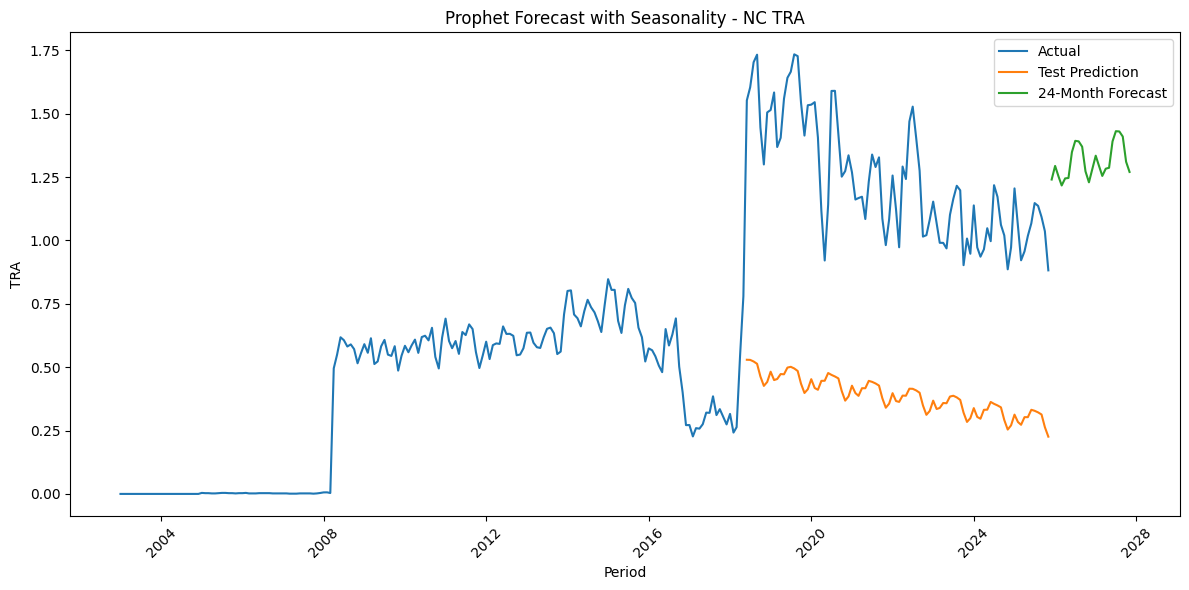

In [11]:
drop_columns = ['ALL', 'OTH', 'COM', 'RES','IND']
keep_columns = ['TRA']
df = ETL(
    csv_filename=csv_filename,
    os_path=path,
    stateid=stateid,
    drop_columns=drop_columns,
    keep_columns=keep_columns
)
target_col = keep_columns[0]

# version 1
df_model = df.copy()
df_model["period"] = pd.to_datetime(df_model["period"])
df_model = df_model.sort_values("period").reset_index(drop=True)

prophet_df = df_model[["period", target_col]].rename(columns={"period": "ds", target_col: "y"})

# Train/test split (70/30)
split_idx = int(len(prophet_df) * 0.7)
train = prophet_df.iloc[:split_idx].copy()
test = prophet_df.iloc[split_idx:].copy()

# Fit Prophet model
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    seasonality_mode="additive"
)
model.fit(train)

# Predict on test set
test_forecast = model.predict(test[["ds"]])
test[f"predicted_{target_col}"] = test_forecast["yhat"].values

# Metrics
rmse = np.sqrt(mean_squared_error(test["y"], test[f"predicted_{target_col}"]))
r2 = r2_score(test["y"], test[f"predicted_{target_col}"])

print("Test RMSE:", rmse)
print("Test R^2:", r2)

# Refit on full dataset for 24-month forecast
final_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    seasonality_mode="additive"
)
final_model.fit(prophet_df)

future = final_model.make_future_dataframe(periods=24, freq="MS")
forecast = final_model.predict(future)

future_forecast = forecast[forecast["ds"] > prophet_df["ds"].max()][["ds", "yhat"]].copy()
future_forecast = future_forecast.rename(
    columns={"ds": "period", "yhat": f"predicted_{target_col}"}
)
future_forecast["stateid"] = stateid
future_forecast["salesUnit"] = "million kilowatt hours"

print(future_forecast[["period", "stateid", "salesUnit", f"predicted_{target_col}"]])

# Plot
plt.figure(figsize=(12, 6))
plt.plot(prophet_df["ds"], prophet_df["y"], label="Actual")
plt.plot(test["ds"], test[f"predicted_{target_col}"], label="Test Prediction")
plt.plot(
    future_forecast["period"],
    future_forecast[f"predicted_{target_col}"],
    label="24-Month Forecast"
)
plt.xlabel("Period")
plt.ylabel(target_col)
plt.title(f"Prophet Forecast with Seasonality - {stateid} {target_col}")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()